In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
path = r"../../data/Global_Economy_Indicators.csv"
df = pd.read_csv(path)
df.head()

,CountryID,Country,Year,AMA exchange rate,IMF based exchange rate,Population,Currency,Per capita GNI,"Agriculture, hunting, forestry, fishing (ISIC A-B)",Changes in inventories,...,Household consumption expenditure (including Non-profit institutions serving households),Imports of goods and services,Manufacturing (ISIC D),"Mining, Manufacturing, Utilities (ISIC C-E)",Other Activities (ISIC J-P),Total Value Added,"Transport, storage and communication (ISIC I)","Wholesale, retail trade, restaurants and hotels (ISIC G-H)",Gross National Income(GNI) in USD,Gross Domestic Product (GDP)
0,4,Afghanistan,1970,0.044998,0.044998,10752971,Afghani,164,8.699174e+08,NaN,...,1.551094e+09,195277226.0,370146827.0,376690811.0,127747843.0,1.731454e+09,83917200.0,226387091.0,1.766528e+09,1.731436e+09
1,4,Afghanistan,1971,0.044998,0.044998,11015857,Afghani,168,9.108281e+08,NaN,...,1.675426e+09,276296480.0,387549502.0,394401164.0,133754097.0,1.812857e+09,87860382.0,237019196.0,1.850122e+09,1.812838e+09
2,4,Afghanistan,1972,0.044998,0.044998,11286753,Afghani,149,8.279453e+08,NaN,...,1.498812e+09,290370350.0,352284669.0,358512865.0,121582672.0,1.647918e+09,79864525.0,215477287.0,1.683948e+09,1.647900e+09
3,4,Afghanistan,1973,0.044998,0.044998,11575305,Afghani,150,8.554869e+08,NaN,...,1.508024e+09,262962880.0,364010279.0,370445793.0,125630236.0,1.702735e+09,82528885.0,222624293.0,1.739998e+09,1.702716e+09
4,4,Afghanistan,1974,0.044998,0.044998,11869879,Afghani,177,1.035913e+09,NaN,...,1.778819e+09,305679151.0,440760406.0,448552790.0,152119162.0,2.061752e+09,99918604.0,269525910.0,2.106420e+09,2.061729e+09


Top 5 countries by average GDP.


In [4]:
gdp = df.groupby(' Country ')[" Gross Domestic Product (GDP) "].mean().sort_values(ascending=False).head(5)

gdp



 Country 
United States      9.321346e+12
Japan              3.417731e+12
China              3.372873e+12
Germany            2.095904e+12
United Kingdom     1.515096e+12
Name:  Gross Domestic Product (GDP) , dtype: float64

Countries with the Household consumption expenditure in the most recent year.

In [5]:
most_recent_year = df[' Year '].max()
recent_consumption = df[df[' Year '] == most_recent_year][[' Country ', ' Household consumption expenditure (including Non-profit institutions serving households) ']]
recent_consumption = recent_consumption.rename(columns={
    ' Household consumption expenditure (including Non-profit institutions serving households) ': ' Household Consumption Expenditure'})
recent_consumption = recent_consumption.sort_values(by=' Household Consumption Expenditure', ascending=False)
recent_consumption

,Country,Household Consumption Expenditure
10144,United States,1.590000e+13
1999,China,6.800000e+12
4680,Japan,2.660000e+12
3484,Germany,2.100000e+12
4212,India,1.910000e+12
...,...,...
6464,Nauru,1.299534e+08
2259,Cook Islands,1.068476e+08
6204,Montserrat,5.465786e+07
9767,Tuvalu,3.655580e+07


Mean GDP per capita.

In [9]:
gdp_capita = df.groupby(' Country ')[[" Gross Domestic Product (GDP) "," Per capita GNI "]].mean()
gdp_capita 

,Gross Domestic Product (GDP),Per capita GNI
Country,,
Afghanistan,7.094304e+09,313.403846
Albania,5.996965e+09,2052.807692
Algeria,8.267588e+10,2530.923077
Andorra,1.719792e+09,26166.826923
Angola,3.650808e+10,1527.615385
...,...,...
Yemen Democratic (Former),3.406513e+08,155.809524
Yugoslavia (Former),5.617382e+10,2561.857143
Zambia,8.983579e+09,696.692308


Max import of goods values

In [10]:
max_imports = df.groupby(' Country ')[' Imports of goods and services '].max().sort_values(ascending=False).head(5)
max_imports 

 Country 
United States      3.400000e+12
China              3.060000e+12
Germany            1.780000e+12
Japan              1.010000e+12
United Kingdom     9.430000e+11
Name:  Imports of goods and services , dtype: float64

Total exports over all years.

In [11]:
total_exports = df.groupby( [" Country "," Year "] )[' Exports of goods and services '].sum().sort_values(ascending=False).head(5)
total_exports 

 Country         Year 
China           2021      3.530000e+12
                2020      2.720000e+12
                2018      2.660000e+12
                2019      2.640000e+12
United States   2019      2.540000e+12
Name:  Exports of goods and services , dtype: float64

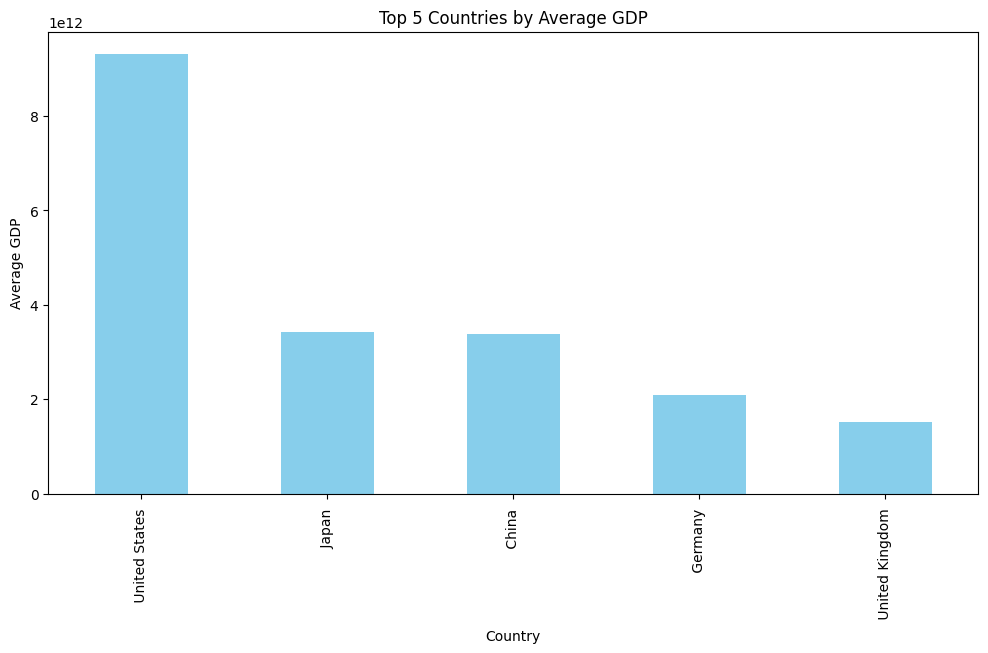

In [13]:
plt.figure(figsize=(12, 6))
gdp.plot(kind='bar', color='skyblue')
plt.title('Top 5 Countries by Average GDP') 
plt.xlabel('Country')
plt.ylabel('Average GDP')
plt.show()

<Figure size 1200x600 with 0 Axes>

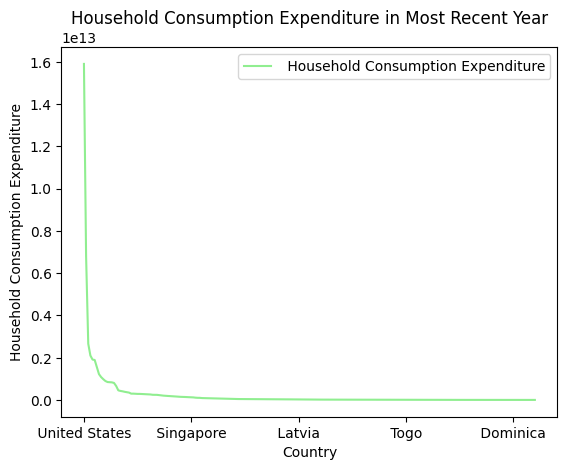

In [14]:
plt.figure(figsize=(12, 6))
recent_consumption.plot(kind='line', color='lightgreen', x = ' Country ', y = ' Household Consumption Expenditure')
plt.title('Household Consumption Expenditure in Most Recent Year')
plt.xlabel('Country')
plt.ylabel('Household Consumption Expenditure')
plt.show()

<Figure size 1200x600 with 0 Axes>

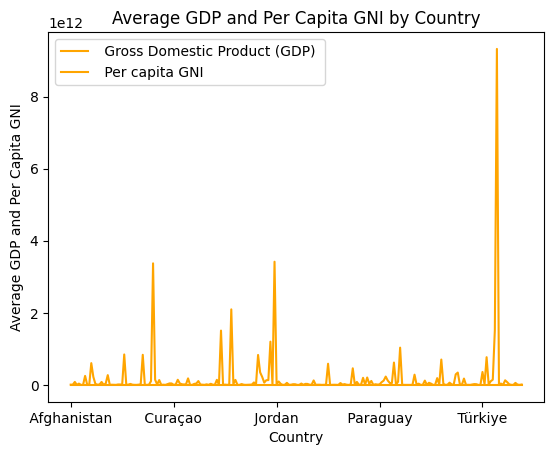

In [17]:
plt.figure(figsize=(12, 6))
gdp_capita.plot(kind='line', color='orange')
plt.title('Average GDP and Per Capita GNI by Country')
plt.xlabel('Country')
plt.ylabel('Average GDP and Per Capita GNI')
plt.show()  

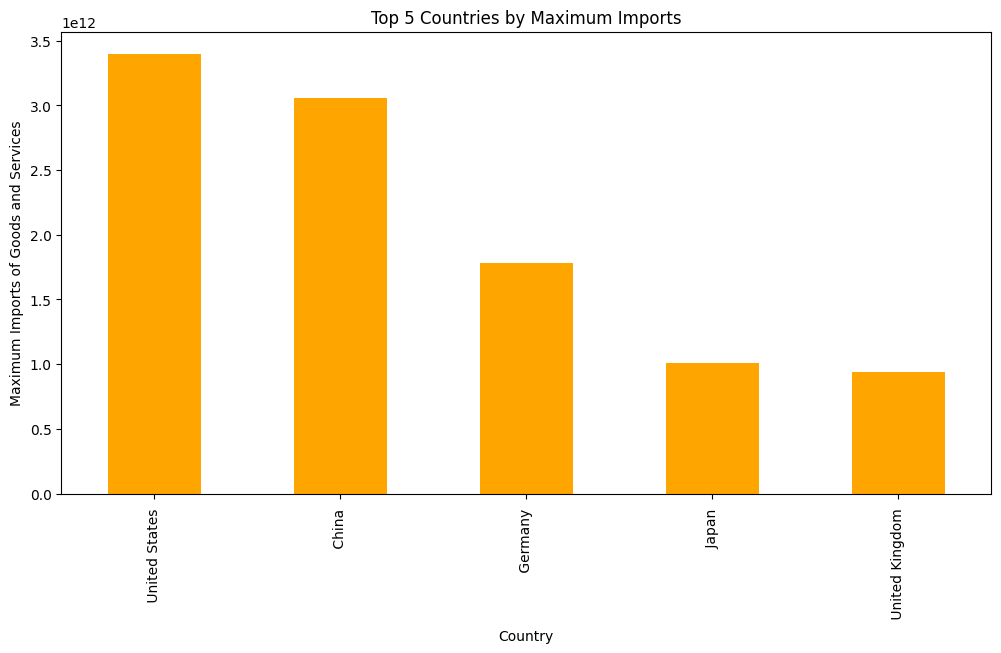

In [18]:
plt.figure(figsize=(12, 6))
max_imports.plot(kind='bar', color='orange')
plt.title('Top 5 Countries by Maximum Imports')
plt.xlabel('Country')
plt.ylabel('Maximum Imports of Goods and Services')
plt.show()

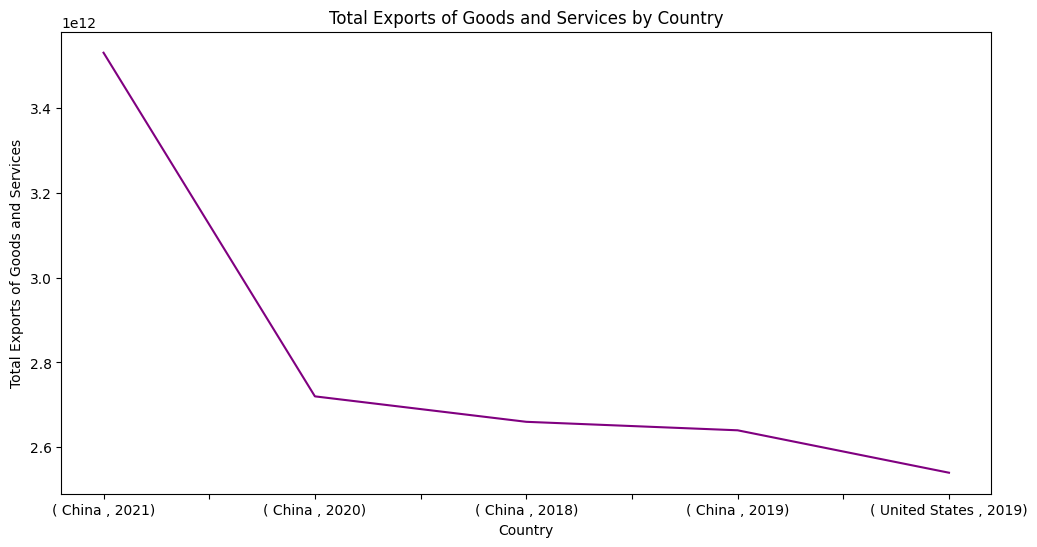

In [19]:
plt.figure(figsize=(12, 6))
total_exports.plot(kind='line', color='purple')
plt.title('Total Exports of Goods and Services by Country')
plt.xlabel('Country')
plt.ylabel('Total Exports of Goods and Services')
plt.show()
